# EDA — Phân tích thống kê trên dữ liệu đã làm sạch (Online Retail II)



In [27]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import skew, kurtosis

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# ---- Đường dẫn (notebook chạy từ notebooks/ hoặc từ gốc repo đều được) ----
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data" / "processed" / "cleaned_transactions.csv"
FIG_DIR = ROOT / "outputs" / "figures"
RES_DIR = ROOT / "outputs" / "results"
REP_DIR = ROOT / "outputs" / "reports"
for d in (FIG_DIR, RES_DIR, REP_DIR):
    d.mkdir(parents=True, exist_ok=True)

# ---- Bảng màu (3 slot đầu của categorical palette, đã validate all-pairs) ----
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#c9c8c3"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": MUTED, "axes.linewidth": 0.8, "axes.labelcolor": INK2,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK2, "ytick.color": INK2, "font.size": 9,
    "grid.color": MUTED, "grid.linewidth": 0.6, "grid.alpha": 0.55,
    "legend.frameon": False, "figure.dpi": 110, "savefig.dpi": 150,
    "savefig.bbox": "tight", "lines.linewidth": 2,
})

def money(x):
    return f"−£{abs(x):,.2f}" if x < 0 else f"£{x:,.2f}"

# Rút gọn nhãn tiền tệ (£25k) để nhãn trục không chồng lên nhau
def gbp_axis(ax, axis="x", nbins=6):
    from matplotlib.ticker import FuncFormatter, MaxNLocator
    fmt = FuncFormatter(lambda v, _: (
        f"{'−' if v < 0 else ''}£{abs(v)/1000:,.0f}k" if abs(v) >= 1000
        else f"{'−' if v < 0 else ''}£{abs(v):,.0f}"))
    a = ax.xaxis if axis == "x" else ax.yaxis
    a.set_major_formatter(fmt)
    a.set_major_locator(MaxNLocator(nbins=nbins))

print("ROOT:", ROOT)

ROOT: /Users/tienanh211/customer_segmentation


---
## Bước 1 — Load dữ liệu đã làm sạch + gắn cờ

Kiểm tra file `cleaned_transactions.csv` còn đầy đủ 4 cột cờ do Task 2 sinh ra:
`IsCancelled`, `HasCustomerID`, `IsServiceCode`, `PriceAnomaly`.

In [28]:
df = pd.read_csv(DATA, parse_dates=["InvoiceDate"])

FLAGS = ["IsCancelled", "HasCustomerID", "IsServiceCode", "PriceAnomaly"]
missing = [c for c in FLAGS if c not in df.columns]
assert not missing, f"THIẾU cột cờ từ Task 2: {missing}"

# Ép kiểu bool phòng trường hợp CSV đọc lên thành string "True"/"False"
for c in FLAGS:
    if df[c].dtype != bool:
        df[c] = df[c].astype(str).str.strip().str.lower().map({"true": True, "false": False})
    df[c] = df[c].astype(bool)

# Cột phái sinh dùng xuyên suốt notebook
df["TotalPrice"] = df["Quantity"] * df["Price"]

print(f"Số dòng : {len(df):,}")
print(f"Số cột  : {df.shape[1]}")
print(f"Khoảng thời gian: {df.InvoiceDate.min():%Y-%m-%d} → {df.InvoiceDate.max():%Y-%m-%d}")
print(f"Số hóa đơn : {df.Invoice.nunique():,} | Số StockCode: {df.StockCode.nunique():,} "
      f"| Số khách có ID: {df['Customer ID'].nunique():,} | Số quốc gia: {df.Country.nunique()}")
df.dtypes.to_frame("dtype")

Số dòng : 536,642
Số cột  : 13
Khoảng thời gian: 2010-12-01 → 2011-12-09
Số hóa đơn : 25,900 | Số StockCode: 4,070 | Số khách có ID: 4,372 | Số quốc gia: 38


,dtype
Invoice,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
Price,float64
Customer ID,float64
Country,object
IsCancelled,bool
HasCustomerID,bool


In [29]:
# Tổng quan mức độ phổ biến của từng cờ
overview = pd.DataFrame({
    "Số dòng": [df[c].sum() for c in FLAGS],
    "% số dòng": [df[c].mean() * 100 for c in FLAGS],
    "Tổng TotalPrice": [df.loc[df[c], "TotalPrice"].sum() for c in FLAGS],
}, index=FLAGS)
overview["% tổng TotalPrice"] = overview["Tổng TotalPrice"] / df.TotalPrice.sum() * 100
display(overview.round(2))

print(f"Tổng TotalPrice toàn bộ dữ liệu: {money(df.TotalPrice.sum())}")
print(f"Số dòng thiếu Customer ID: {(~df.HasCustomerID).sum():,} ({(~df.HasCustomerID).mean()*100:.2f}%)")

,Số dòng,% số dòng,Tổng TotalPrice,% tổng TotalPrice
IsCancelled,9251,1.72,"-893,979.73",-9.19
HasCustomerID,401605,74.84,"8,278,537.42",85.12
IsServiceCode,2730,0.51,"195,336.86",2.01
PriceAnomaly,2512,0.47,"-22,124.12",-0.23


Tổng TotalPrice toàn bộ dữ liệu: £9,726,024.95
Số dòng thiếu Customer ID: 135,037 (25.16%)


---
## Bước 2 — Thống kê mô tả, so sánh nhóm hủy đơn / không hủy

Giả thuyết cần kiểm chứng: **`IsCancelled = True` luôn đi kèm `Quantity` âm**.
Nếu đúng, đây là căn cứ để loại các dòng này khi tính Monetary — vì cộng dồn `Quantity` âm
sẽ làm **giảm ảo** giá trị chi tiêu thật của khách hàng.

In [30]:
desc = df.groupby("IsCancelled")[["Quantity", "Price", "TotalPrice"]].describe().T
desc.round(3)

IsCancelled           False       True 
Quantity   count 527,391.00    9,251.00
           mean       10.31      -29.79
           std       160.37    1,148.00
           min    -9,600.00  -80,995.00
           25%         1.00       -6.00
           50%         3.00       -2.00
           75%        11.00       -1.00
           max    80,995.00       -1.00
Price      count 527,391.00    9,251.00
           mean        3.86       48.57
           std        41.96      667.93
           min   -11,062.06        0.01
           25%         1.25        1.45
           50%         2.08        2.95
           75%         4.13        5.95
           max    13,541.33   38,970.00
TotalPrice count 527,391.00    9,251.00
           mean       20.14      -96.64
           std       271.91    2,043.92
           min   -11,062.06 -168,469.60
           25%         3.78      -17.70
           50%         9.90       -8.50
           75%        17.70       -3.70
           max   168,469.60       -0.12

In [31]:
sign_tab = pd.crosstab(df.IsCancelled, np.sign(df.Quantity).map({-1: "Quantity < 0", 0: "= 0", 1: "Quantity > 0"}))
display(sign_tab)

pct_neg_cancel = df.loc[df.IsCancelled, "Quantity"].lt(0).mean() * 100
print(f"→ Trong nhóm IsCancelled = True, tỷ lệ Quantity âm: {pct_neg_cancel:.2f}%")

summary_cancel = df.groupby("IsCancelled")["TotalPrice"].agg(
    rows="size", total="sum", mean="mean", median="median", min="min", max="max")
display(summary_cancel.round(2))

gross_pos = df.loc[~df.IsCancelled, "TotalPrice"].sum()
gross_neg = df.loc[df.IsCancelled, "TotalPrice"].sum()
print(f"Doanh thu nhóm KHÔNG hủy : {money(gross_pos)}")
print(f"Giá trị nhóm HỦY         : {money(gross_neg)}  "
      f"(≈ {abs(gross_neg)/gross_pos*100:.2f}% doanh thu nhóm không hủy)")
print(f"Nếu cộng dồn cả 2 nhóm   : {money(df.TotalPrice.sum())}  ← Monetary bị GIẢM ẢO")

Quantity,Quantity < 0,Quantity > 0
IsCancelled,,
False,1336,526055
True,9251,0


→ Trong nhóm IsCancelled = True, tỷ lệ Quantity âm: 100.00%


,rows,total,mean,median,min,max
IsCancelled,,,,,,
False,527391,"10,620,004.68",20.14,9.90,"-11,062.06","168,469.60"
True,9251,"-893,979.73",-96.64,-8.50,"-168,469.60",-0.12


Doanh thu nhóm KHÔNG hủy : £10,620,004.68
Giá trị nhóm HỦY         : −£893,979.73  (≈ 8.42% doanh thu nhóm không hủy)
Nếu cộng dồn cả 2 nhóm   : £9,726,024.95  ← Monetary bị GIẢM ẢO


In [32]:
neg_not_cancel = df[(~df.IsCancelled) & (df.Quantity < 0)]
print(f"Số dòng Quantity < 0 nhưng IsCancelled = False: {len(neg_not_cancel):,}")
print(f"  - Tổng TotalPrice: {money(neg_not_cancel.TotalPrice.sum())}")
print(f"  - Có Price = 0   : {(neg_not_cancel.Price == 0).sum():,} / {len(neg_not_cancel):,}")
print(f"  - Có Customer ID : {neg_not_cancel.HasCustomerID.sum():,} / {len(neg_not_cancel):,}")
print(f"  - Được gắn PriceAnomaly: {neg_not_cancel.PriceAnomaly.sum():,}")
display(neg_not_cancel.Description.value_counts(dropna=False).head(8).to_frame("số dòng"))
neg_not_cancel.head(5)[["Invoice", "StockCode", "Description", "Quantity", "Price", "TotalPrice", "PriceAnomaly"]]

Số dòng Quantity < 0 nhưng IsCancelled = False: 1,336
  - Tổng TotalPrice: £0.00
  - Có Price = 0   : 1,336 / 1,336
  - Có Customer ID : 0 / 1,336
  - Được gắn PriceAnomaly: 1,336


,số dòng
Description,
NaN,862
check,120
damages,45
damaged,42
?,41
sold as set on dotcom,20
Damaged,14
thrown away,9


,Invoice,StockCode,Description,Quantity,Price,TotalPrice,PriceAnomaly
2362,536589,21777,NaN,-10,0.00,-0.00,True
4286,536764,84952C,NaN,-38,0.00,-0.00,True
7086,536996,22712,NaN,-20,0.00,-0.00,True
7087,536997,22028,NaN,-20,0.00,-0.00,True
7088,536998,85067,NaN,-6,0.00,-0.00,True


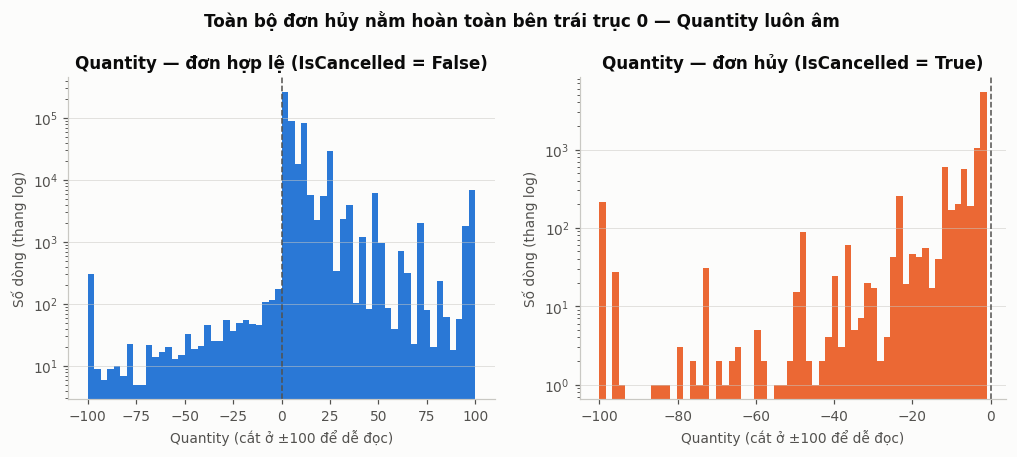

In [33]:
# Trực quan hóa: phân phối Quantity của 2 nhóm (thang log để thấy được đuôi phân phối)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].hist(df.loc[~df.IsCancelled, "Quantity"].clip(-100, 100), bins=60, color=BLUE)
axes[0].set_title("Quantity — đơn hợp lệ (IsCancelled = False)")
axes[0].axvline(0, color=INK2, lw=1, ls="--")

axes[1].hist(df.loc[df.IsCancelled, "Quantity"].clip(-100, 100), bins=60, color=ORANGE)
axes[1].set_title("Quantity — đơn hủy (IsCancelled = True)")
axes[1].axvline(0, color=INK2, lw=1, ls="--")

for ax in axes:
    ax.set_yscale("log")
    ax.set_xlabel("Quantity (cắt ở ±100 để dễ đọc)")
    ax.set_ylabel("Số dòng (thang log)")
    ax.grid(axis="y")
fig.suptitle("Toàn bộ đơn hủy nằm hoàn toàn bên trái trục 0 — Quantity luôn âm",
             fontsize=11, fontweight="bold", color=INK, y=1.04)
plt.show()

---
## Bước 3 — Ảnh hưởng của mã dịch vụ (`IsServiceCode`) lên tổng Monetary

Các mã `POST`, `DOT`, `M`, `C2`, `BANK CHARGES`, `CRUK`… **không phản ánh hành vi mua sản phẩm thật**.
Cần trả lời: tỷ trọng của chúng có nhỏ không, và có dòng giá trị bất thường lớn nào không?

In [34]:
# Theo yêu cầu đề bài — tổng Price theo nhóm mã dịch vụ
print("Tổng Price theo IsServiceCode:")
display(df.groupby("IsServiceCode")["Price"].sum().round(2).to_frame("sum(Price)"))

# Nhưng chỉ tiêu đúng để đánh giá Monetary là TotalPrice
svc_agg = df.groupby("IsServiceCode")["TotalPrice"].agg(
    rows="size", total="sum", mean="mean", median="median", min="min", max="max")
svc_agg["% số dòng"] = svc_agg["rows"] / len(df) * 100
svc_agg["% tổng TotalPrice"] = svc_agg["total"] / df.TotalPrice.sum() * 100
display(svc_agg.round(2))

Tổng Price theo IsServiceCode:


,sum(Price)
IsServiceCode,
False,"1,996,454.46"
True,"489,636.51"


,rows,total,mean,median,min,max,% số dòng,% tổng TotalPrice
IsServiceCode,,,,,,,,
False,533912,"9,530,688.09",17.85,9.84,"-168,469.60","168,469.60",99.49,97.99
True,2730,"195,336.86",71.55,50.00,"-38,970.00","8,142.75",0.51,2.01


In [35]:
svc = df[df.IsServiceCode]
by_code = svc.groupby("StockCode").agg(
    rows=("TotalPrice", "size"),
    net_total=("TotalPrice", "sum"),
    mean=("TotalPrice", "mean"),
    max=("TotalPrice", "max"),
    min=("TotalPrice", "min"),
    n_cancelled=("IsCancelled", "sum"),
    n_has_custid=("HasCustomerID", "sum"),
).sort_values("net_total", ascending=False)
by_code["mô tả"] = svc.groupby("StockCode")["Description"].agg(lambda s: s.dropna().mode().iat[0] if s.notna().any() else "")
display(by_code.round(2))

print(f"Mã dịch vụ chiếm {len(svc)/len(df)*100:.2f}% số dòng "
      f"nhưng {svc.TotalPrice.sum()/df.TotalPrice.sum()*100:.2f}% tổng TotalPrice.")

,rows,net_total,mean,max,min,n_cancelled,n_has_custid,mô tả
StockCode,,,,,,,,
DOT,710,"206,245.48",290.49,"4,505.17",-3.29,1,16,DOTCOM POSTAGE
POST,1257,"66,248.64",52.70,"8,142.75","-8,142.75",126,1197,POSTAGE
C2,144,"6,986.00",48.51,150.00,-50.00,2,134,CARRIAGE
BANK CHARGES,37,"-7,175.64",-193.94,15.00,"-1,050.15",25,12,Bank Charges
CRUK,16,"-7,933.43",-495.84,-1.60,"-1,100.44",16,16,CRUK Commission
M,566,"-69,034.19",-121.97,"4,287.63","-38,970.00",244,460,Manual


Mã dịch vụ chiếm 0.51% số dòng nhưng 2.01% tổng TotalPrice.


In [36]:
# Các dòng mã dịch vụ có giá trị tuyệt đối lớn nhất — nguồn gây nhiễu Monetary
top_svc = svc.reindex(svc.TotalPrice.abs().sort_values(ascending=False).index).head(10)
top_svc[["Invoice", "StockCode", "Description", "Quantity", "Price", "TotalPrice",
         "Customer ID", "Country", "IsCancelled"]]

,Invoice,StockCode,Description,Quantity,Price,TotalPrice,Customer ID,Country,IsCancelled
220826,C556445,M,Manual,-1,"38,970.00","-38,970.00","15,098.00",United Kingdom,True
418855,C573079,M,Manual,-2,"4,161.06","-8,322.12","12,536.00",France,True
171873,551697,POST,POSTAGE,1,"8,142.75","8,142.75","16,029.00",United Kingdom,False
171769,C551685,POST,POSTAGE,-1,"8,142.75","-8,142.75","16,029.00",United Kingdom,True
171882,C551699,M,Manual,-1,"6,930.00","-6,930.00","16,029.00",United Kingdom,True
295394,562955,DOT,DOTCOM POSTAGE,1,"4,505.17","4,505.17",NaN,United Kingdom,False
265857,560373,M,Manual,1,"4,287.63","4,287.63",NaN,United Kingdom,False
265856,C560372,M,Manual,-1,"4,287.63","-4,287.63","17,448.00",United Kingdom,True
418857,573080,M,Manual,1,"4,161.06","4,161.06","12,536.00",France,False
418854,573077,M,Manual,1,"4,161.06","4,161.06","12,536.00",France,False


In [37]:
# Mã dịch vụ bóp méo Monetary của TỪNG khách hàng ở mức nào?
base = df[(~df.IsCancelled) & df.HasCustomerID]
m_with = base.groupby("Customer ID").TotalPrice.sum()
m_without = base[~base.IsServiceCode].groupby("Customer ID").TotalPrice.sum()

cmp = pd.concat([m_with.rename("Monetary_có_svc"), m_without.rename("Monetary_không_svc")], axis=1).fillna(0)
cmp["chênh_lệch"] = cmp["Monetary_có_svc"] - cmp["Monetary_không_svc"]
cmp["% thổi_phồng"] = np.where(cmp["Monetary_không_svc"] > 0,
                               cmp["chênh_lệch"] / cmp["Monetary_không_svc"] * 100, np.nan)

affected = cmp[cmp["chênh_lệch"].abs() > 0.01]
print(f"Số khách hàng có Monetary bị mã dịch vụ tác động: {len(affected):,} / {len(cmp):,} "
      f"({len(affected)/len(cmp)*100:.1f}%)")
print(f"Mức thổi phồng trung vị trong nhóm bị tác động : {affected['% thổi_phồng'].median():.2f}%")
print(f"Số khách bị thổi phồng > 10% Monetary          : {(cmp['% thổi_phồng'] > 10).sum():,}")
print(f"Số khách bị thổi phồng > 50% Monetary          : {(cmp['% thổi_phồng'] > 50).sum():,}")
display(cmp.sort_values("% thổi_phồng", ascending=False).head(8).round(2))

Số khách hàng có Monetary bị mã dịch vụ tác động: 542 / 4,339 (12.5%)
Mức thổi phồng trung vị trong nhóm bị tác động : 9.47%
Số khách bị thổi phồng > 10% Monetary          : 257
Số khách bị thổi phồng > 50% Monetary          : 17


,Monetary_có_svc,Monetary_không_svc,chênh_lệch,% thổi_phồng
Customer ID,,,,
"15,581.00","3,675.77",717.43,"2,958.34",412.35
"15,935.00",416.86,108.04,308.82,285.84
"12,536.00","12,601.83","4,279.71","8,322.12",194.46
"12,744.00","21,279.29","9,120.39","12,158.90",133.32
"16,257.00",46.95,21.95,25.00,113.90
"12,365.00",641.38,320.69,320.69,100.00
"12,669.00","2,744.03","1,427.73","1,316.30",92.20
"12,757.00","7,834.65","4,176.75","3,657.90",87.58


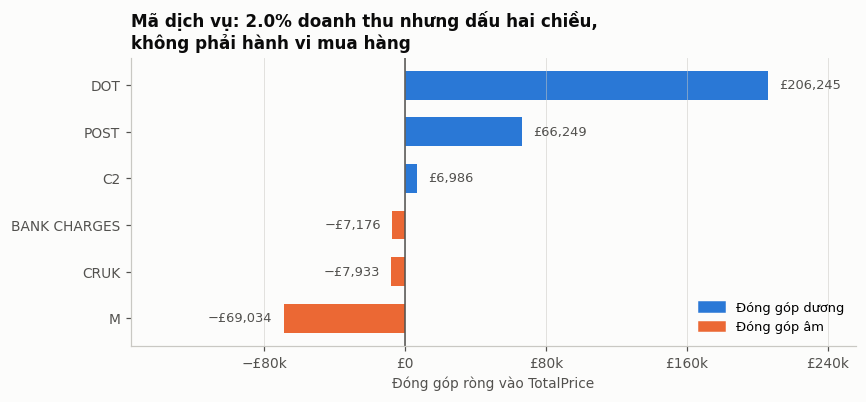

In [38]:
# Biểu đồ: đóng góp ròng của từng mã dịch vụ vào TotalPrice
plot_df = by_code["net_total"].sort_values()
colors = [ORANGE if v < 0 else BLUE for v in plot_df]

fig, ax = plt.subplots(figsize=(8.5, 3.4))
ax.barh(plot_df.index, plot_df.values, color=colors, height=0.62)
ax.axvline(0, color=INK2, lw=1)
pad = plot_df.abs().max() * 0.03
for y, v in zip(plot_df.index, plot_df.values):
    label = f"{'−' if v < 0 else ''}£{abs(v):,.0f}"
    ax.text(v + (pad if v >= 0 else -pad), y, label,
            va="center", ha="left" if v >= 0 else "right", fontsize=8.5, color=INK2)
ax.set_xlim(plot_df.min() - plot_df.abs().max() * 0.42, plot_df.max() * 1.24)
ax.set_xlabel("Đóng góp ròng vào TotalPrice")
ax.set_title("Mã dịch vụ: 2.0% doanh thu nhưng dấu hai chiều,\nkhông phải hành vi mua hàng", loc="left")
ax.grid(axis="x")
gbp_axis(ax, nbins=6)
handles = [plt.Rectangle((0, 0), 1, 1, color=BLUE), plt.Rectangle((0, 0), 1, 1, color=ORANGE)]
ax.legend(handles, ["Đóng góp dương", "Đóng góp âm"], loc="lower right", fontsize=8.5)
plt.show()

In [39]:
# còn mã phi-sản-phẩm nào CHƯA được gắn IsServiceCode?
not_5digit = ~df.StockCode.astype(str).str.match(r"^\d{5}")
unflagged = df[not_5digit & ~df.IsServiceCode]

gap = unflagged.groupby("StockCode").agg(
    rows=("TotalPrice", "size"),
    net_total=("TotalPrice", "sum"),
    desc=("Description", lambda s: s.dropna().iat[0] if s.notna().any() else ""),
).sort_values("net_total", key=abs, ascending=False)
display(gap.head(10).round(2))
print(f"Tổng ảnh hưởng ròng của các mã phi-sản-phẩm CHƯA gắn cờ: "
      f"{money(gap.head(4).net_total.sum())}")

,rows,net_total,desc
StockCode,,,
AMAZONFEE,34,"-221,520.50",AMAZON FEE
B,3,"-11,062.06",Adjust bad debt
D,77,"-5,696.22",Discount
S,62,"-3,039.65",SAMPLES
gift_0001_30,8,175.53,Dotcomgiftshop Gift Voucher £30.00
gift_0001_50,4,167.56,Dotcomgiftshop Gift Voucher £50.00
gift_0001_20,10,167.05,Dotcomgiftshop Gift Voucher £20.00
DCGSSBOY,11,150.55,BOYS PARTY BAG
DCGSSGIRL,13,144.43,GIRLS PARTY BAG


Tổng ảnh hưởng ròng của các mã phi-sản-phẩm CHƯA gắn cờ: −£241,318.43


---
## Bước 4 — Trực quan hóa phân phối trên tập giao dịch hợp lệ

Loại **tạm** `IsCancelled` và `IsServiceCode` khi vẽ để phân phối không bị nhiễu bởi các trường hợp đặc biệt.

In [40]:
valid = df[(~df.IsCancelled) & (~df.IsServiceCode)].copy()
print(f"Tập hợp lệ: {len(valid):,} dòng ({len(valid)/len(df)*100:.2f}% tổng số dòng)")
display(valid[["Quantity", "Price", "TotalPrice"]].describe().round(3))

print(f"Trong tập hợp lệ vẫn còn: TotalPrice = 0 → {(valid.TotalPrice == 0).sum():,} dòng | "
      f"TotalPrice < 0 → {(valid.TotalPrice < 0).sum():,} dòng")
display(valid[valid.TotalPrice < 0][["Invoice", "StockCode", "Description", "Quantity", "Price", "TotalPrice"]])

Tập hợp lệ: 525,075 dòng (97.84% tổng số dòng)


,Quantity,Price,TotalPrice
count,"525,075.00","525,075.00","525,075.00"
mean,10.33,3.27,19.52
std,160.66,32.68,271.23
min,"-9,600.00","-11,062.06","-11,062.06"
25%,1.00,1.25,3.75
50%,4.00,2.08,9.90
75%,12.00,4.13,17.70
max,"80,995.00","13,541.33","168,469.60"


Trong tập hợp lệ vẫn còn: TotalPrice = 0 → 2,496 dòng | TotalPrice < 0 → 2 dòng


,Invoice,StockCode,Description,Quantity,Price,TotalPrice
297646,A563186,B,Adjust bad debt,1,"-11,062.06","-11,062.06"
297647,A563187,B,Adjust bad debt,1,"-11,062.06","-11,062.06"


Dòng hợp lệ & TotalPrice > 0: 522,577


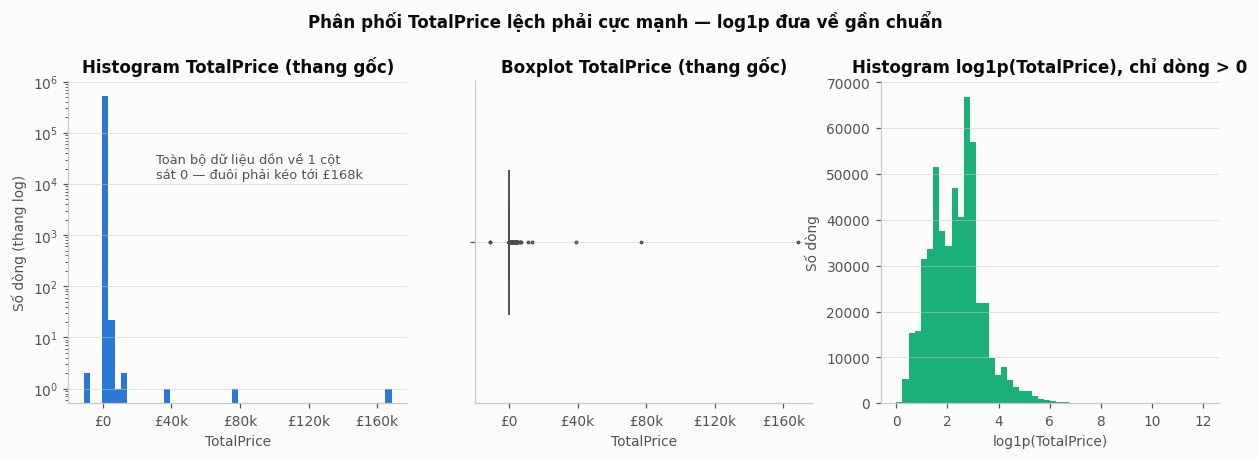

In [41]:
# Chỉ giữ dòng có giá trị dương để vẽ phân phối & log-transform (log1p không nhận giá trị âm)
pos = valid[valid.TotalPrice > 0]
print(f"Dòng hợp lệ & TotalPrice > 0: {len(pos):,}")

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))

axes[0].hist(valid.TotalPrice, bins=50, color=BLUE)
axes[0].set_yscale("log")
axes[0].set_title("Histogram TotalPrice (thang gốc)")
axes[0].set_xlabel("TotalPrice")
axes[0].set_ylabel("Số dòng (thang log)")
axes[0].annotate("Toàn bộ dữ liệu dồn về 1 cột\nsát 0 — đuôi phải kéo tới £168k",
                 xy=(0.26, 0.70), xycoords="axes fraction", fontsize=8.5, color=INK2)
gbp_axis(axes[0], nbins=5)

sns.boxplot(x=valid.TotalPrice, ax=axes[1], color=BLUE, fliersize=1.5,
            linewidth=1, width=0.45)
axes[1].set_title("Boxplot TotalPrice (thang gốc)")
axes[1].set_xlabel("TotalPrice")
gbp_axis(axes[1], nbins=5)

axes[2].hist(np.log1p(pos.TotalPrice), bins=50, color=AQUA)
axes[2].set_title("Histogram log1p(TotalPrice), chỉ dòng > 0")
axes[2].set_xlabel("log1p(TotalPrice)")
axes[2].set_ylabel("Số dòng")

for ax in axes:
    ax.grid(axis="y")
fig.suptitle("Phân phối TotalPrice lệch phải cực mạnh — log1p đưa về gần chuẩn",
             fontsize=11, fontweight="bold", color=INK, y=1.05)
plt.show()

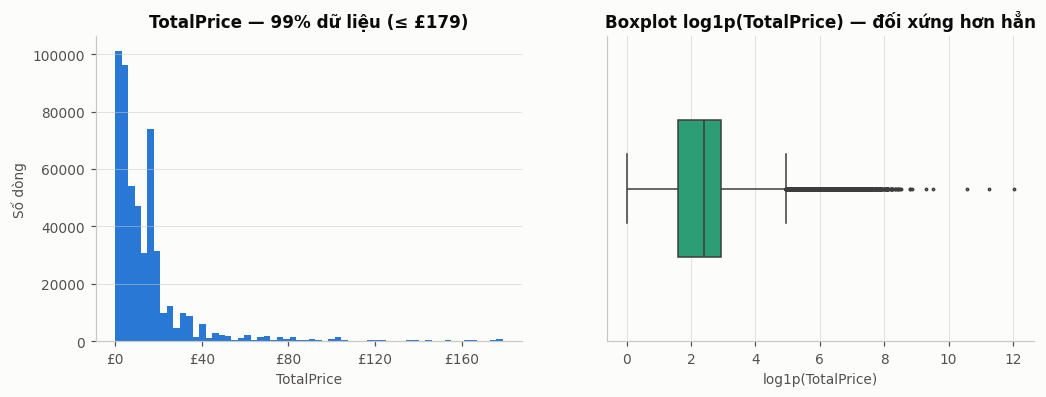

In [42]:
# Zoom vào vùng 99% dữ liệu để thấy hình dạng thật của phân phối
p99 = pos.TotalPrice.quantile(0.99)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].hist(pos.loc[pos.TotalPrice <= p99, "TotalPrice"], bins=60, color=BLUE)
axes[0].set_title(f"TotalPrice — 99% dữ liệu (≤ £{p99:,.0f})")
axes[0].set_xlabel("TotalPrice")
axes[0].set_ylabel("Số dòng")
axes[0].grid(axis="y")
gbp_axis(axes[0], nbins=6)

sns.boxplot(x=np.log1p(pos.TotalPrice), ax=axes[1], color=AQUA, fliersize=1.5,
            linewidth=1, width=0.45)
axes[1].set_title("Boxplot log1p(TotalPrice) — đối xứng hơn hẳn")
axes[1].set_xlabel("log1p(TotalPrice)")
axes[1].set_ylabel("")
axes[1].set_yticks([])
axes[1].grid(axis="x")
plt.show()

---
## Bước 5 — Xác định outlier bằng IQR trên tập hợp lệ

In [43]:
Q1, Q3 = valid["TotalPrice"].quantile([0.25, 0.75])
IQR = Q3 - Q1
upper, lower = Q3 + 1.5 * IQR, Q1 - 1.5 * IQR

outliers = valid[valid["TotalPrice"] > upper]
low_outliers = valid[valid["TotalPrice"] < lower]

print(f"Q1 = {Q1:,.2f} | Q3 = {Q3:,.2f} | IQR = {IQR:,.2f}")
print(f"Ngưỡng trên = Q3 + 1.5·IQR = {upper:,.2f} | Ngưỡng dưới = {lower:,.2f}")
print(f"\nOutlier trên : {len(outliers):,} dòng ({len(outliers)/len(valid)*100:.2f}% tập hợp lệ) "
      f"— chiếm {outliers.TotalPrice.sum()/valid.TotalPrice.sum()*100:.2f}% doanh thu hợp lệ")
print(f"Outlier dưới : {len(low_outliers):,} dòng")

Q1 = 3.75 | Q3 = 17.70 | IQR = 13.95
Ngưỡng trên = Q3 + 1.5·IQR = 38.63 | Ngưỡng dưới = -17.18

Outlier trên : 41,124 dòng (7.83% tập hợp lệ) — chiếm 50.77% doanh thu hợp lệ
Outlier dưới : 2 dòng


In [44]:
# Outlier là hành vi thật hay lỗi dữ liệu? So sánh chân dung outlier vs toàn tập hợp lệ
profile = pd.DataFrame({
    "Outlier (> Q3+1.5·IQR)": [
        len(outliers), outliers.Quantity.median(), outliers.Price.median(),
        outliers.HasCustomerID.mean() * 100, (outliers.Country != "United Kingdom").mean() * 100,
        outliers.loc[outliers.HasCustomerID, "Customer ID"].nunique(),
    ],
    "Toàn tập hợp lệ": [
        len(valid), valid.Quantity.median(), valid.Price.median(),
        valid.HasCustomerID.mean() * 100, (valid.Country != "United Kingdom").mean() * 100,
        valid.loc[valid.HasCustomerID, "Customer ID"].nunique(),
    ],
}, index=["Số dòng", "Quantity trung vị", "Price trung vị", "% có Customer ID",
          "% ngoài United Kingdom", "Số khách hàng duy nhất"])
display(profile.round(2))

top_countries = (pd.concat([
    outliers.Country.value_counts(normalize=True).mul(100).rename("% trong outlier"),
    valid.Country.value_counts(normalize=True).mul(100).rename("% trong tập hợp lệ"),
], axis=1).sort_values("% trong outlier", ascending=False).head(10))
top_countries["Tỷ lệ vượt trội (lần)"] = top_countries["% trong outlier"] / top_countries["% trong tập hợp lệ"]
display(top_countries.round(2))

,Outlier (> Q3+1.5·IQR),Toàn tập hợp lệ
Số dòng,"41,124.00","525,075.00"
Quantity trung vị,24.00,4.00
Price trung vị,2.55,2.08
% có Customer ID,87.26,74.50
% ngoài United Kingdom,18.77,8.32
Số khách hàng duy nhất,"2,835.00","4,335.00"


,% trong outlier,% trong tập hợp lệ,Tỷ lệ vượt trội (lần)
Country,,,
United Kingdom,81.23,91.68,0.89
Netherlands,4.11,0.44,9.28
EIRE,2.95,1.48,2.00
Germany,2.32,1.65,1.41
France,2.10,1.54,1.36
Australia,1.70,0.23,7.53
Switzerland,0.80,0.37,2.18
Norway,0.59,0.20,2.97
Japan,0.52,0.06,8.51


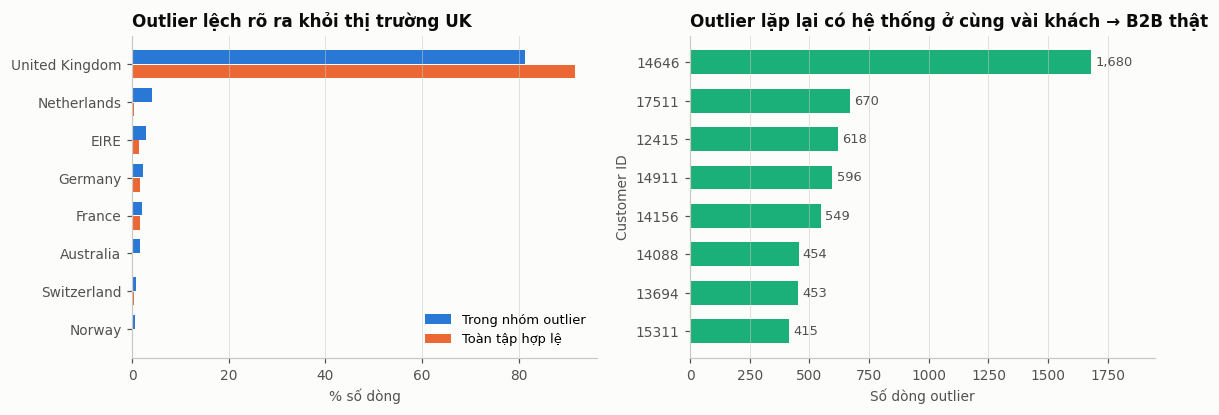

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

# (a) Quốc gia — outlier lệch mạnh ra khỏi UK
cty = top_countries.head(8).iloc[::-1]
y = np.arange(len(cty))
axes[0].barh(y + 0.19, cty["% trong outlier"], height=0.36, color=BLUE, label="Trong nhóm outlier")
axes[0].barh(y - 0.19, cty["% trong tập hợp lệ"], height=0.36, color=ORANGE, label="Toàn tập hợp lệ")
axes[0].set_yticks(y, cty.index)
axes[0].set_xlabel("% số dòng")
axes[0].set_title("Outlier lệch rõ ra khỏi thị trường UK", loc="left")
axes[0].legend(loc="lower right", fontsize=8.5)
axes[0].grid(axis="x")

# (b) Khách hàng lặp lại nhiều dòng outlier → dấu hiệu B2B, không phải lỗi nhập liệu
rep = outliers.loc[outliers.HasCustomerID, "Customer ID"].value_counts().head(8).iloc[::-1]
axes[1].barh([f"{int(i)}" for i in rep.index], rep.values, color=AQUA, height=0.62)
for i, v in enumerate(rep.values):
    axes[1].text(v + 18, i, f"{v:,}", va="center", fontsize=8.5, color=INK2)
axes[1].set_xlabel("Số dòng outlier")
axes[1].set_ylabel("Customer ID")
axes[1].set_xlim(0, rep.max() * 1.16)
axes[1].set_title("Outlier lặp lại có hệ thống ở cùng vài khách → B2B thật", loc="left")
axes[1].grid(axis="x")

plt.show()

In [46]:
# Xem cụ thể các outlier lớn nhất
outliers.nlargest(12, "TotalPrice")[
    ["Invoice", "StockCode", "Description", "Quantity", "Price", "TotalPrice",
     "Customer ID", "Country", "InvoiceDate"]]

,Invoice,StockCode,Description,Quantity,Price,TotalPrice,Customer ID,Country,InvoiceDate
535160,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,"168,469.60","16,446.00",United Kingdom,2011-12-09 09:15:00
61006,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,"77,183.60","12,346.00",United Kingdom,2011-01-18 10:01:00
220816,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,"38,970.00","15,098.00",United Kingdom,2011-06-10 15:28:00
14757,537632,AMAZONFEE,AMAZON FEE,1,"13,541.33","13,541.33",NaN,United Kingdom,2010-12-07 15:08:00
297645,A563185,B,Adjust bad debt,1,"11,062.06","11,062.06",NaN,United Kingdom,2011-08-12 14:50:00
345627,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,5.06,"7,144.72","17,450.00",United Kingdom,2011-09-20 11:05:00
52169,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,"6,539.40","15,749.00",United Kingdom,2011-01-11 12:55:00
159101,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,"6,539.40","15,749.00",United Kingdom,2011-04-18 13:20:00
418088,573003,23084,RABBIT NIGHT LIGHT,2400,2.08,"4,992.00","14,646.00",Netherlands,2011-10-27 12:11:00
52167,540815,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930,2.55,"4,921.50","15,749.00",United Kingdom,2011-01-11 12:55:00


In [47]:
# Đối chiếu 2 dòng nghi vấn lớn nhất với hóa đơn hủy tương ứng
for inv, code_ in [("581483", "23843"), ("541431", "23166")]:
    related = df[df.Invoice.astype(str).str.contains(inv[1:], na=False) & (df.StockCode == code_)]
    display(related[["Invoice", "StockCode", "Quantity", "Price", "TotalPrice",
                     "Customer ID", "Country", "IsCancelled", "InvoiceDate"]])

,Invoice,StockCode,Quantity,Price,TotalPrice,Customer ID,Country,IsCancelled,InvoiceDate
535160,581483,23843,80995,2.08,"168,469.60","16,446.00",United Kingdom,False,2011-12-09 09:15:00


,Invoice,StockCode,Quantity,Price,TotalPrice,Customer ID,Country,IsCancelled,InvoiceDate
61006,541431,23166,74215,1.04,"77,183.60","12,346.00",United Kingdom,False,2011-01-18 10:01:00


In [48]:
# Xuất file outlier chi tiết
out_cols = ["Invoice", "StockCode", "Description", "Quantity", "Price", "TotalPrice",
            "Customer ID", "Country", "InvoiceDate",
            "IsCancelled", "HasCustomerID", "IsServiceCode", "PriceAnomaly"]
export = outliers[out_cols].sort_values("TotalPrice", ascending=False).copy()
export["OutlierType"] = "IQR_upper"
export["IQR_upper_threshold"] = round(upper, 2)
export["TimesOverThreshold"] = (export.TotalPrice / upper).round(2)

# 3 dấu hiệu nhận biết hành vi B2B/wholesale thật (thay vì lỗi nhập liệu)
repeat_cust = outliers.loc[outliers.HasCustomerID, "Customer ID"].value_counts()
repeat_cust = set(repeat_cust[repeat_cust >= 10].index)
export["SignalBulkQuantity"] = export.Quantity >= 50
export["SignalNonUK"] = export.Country != "United Kingdom"
export["SignalRepeatOutlierCustomer"] = export["Customer ID"].isin(repeat_cust)
export["LikelyB2B"] = export[["SignalBulkQuantity", "SignalNonUK",
                              "SignalRepeatOutlierCustomer"]].any(axis=1)
# Cờ riêng cho mã phi-sản-phẩm chưa được Task 2 gắn cờ (AMAZONFEE, B, D, S)
export["IsUnflaggedServiceCode"] = export.StockCode.astype(str).str.upper().isin(
    {"AMAZONFEE", "B", "D", "S"})

path = RES_DIR / "outliers_detected.csv"
export.to_csv(path, index=False)
print(f"✅ Đã lưu {len(export):,} dòng outlier → {path.relative_to(ROOT)}")
print(f"   LikelyB2B (hành vi thật)          : {export.LikelyB2B.sum():,} "
      f"({export.LikelyB2B.mean()*100:.1f}%)")
print(f"   - mua sỉ ≥ 50 sp                  : {export.SignalBulkQuantity.sum():,}")
print(f"   - ngoài United Kingdom            : {export.SignalNonUK.sum():,}")
print(f"   - khách có ≥ 10 dòng outlier      : {export.SignalRepeatOutlierCustomer.sum():,}")
print(f"   Mã phi-sản-phẩm chưa gắn cờ       : {export.IsUnflaggedServiceCode.sum():,}")
export.head(5)

✅ Đã lưu 41,124 dòng outlier → outputs/results/outliers_detected.csv
   LikelyB2B (hành vi thật)          : 31,689 (77.1%)
   - mua sỉ ≥ 50 sp                  : 11,229
   - ngoài United Kingdom            : 7,721
   - khách có ≥ 10 dòng outlier      : 29,474
   Mã phi-sản-phẩm chưa gắn cờ       : 3


,Invoice,StockCode,Description,Quantity,Price,TotalPrice,Customer ID,Country,InvoiceDate,IsCancelled,HasCustomerID,IsServiceCode,PriceAnomaly,OutlierType,IQR_upper_threshold,TimesOverThreshold,SignalBulkQuantity,SignalNonUK,SignalRepeatOutlierCustomer,LikelyB2B,IsUnflaggedServiceCode
535160,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,"168,469.60","16,446.00",United Kingdom,2011-12-09 09:15:00,False,True,False,False,IQR_upper,38.63,"4,361.67",True,False,False,True,False
61006,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,"77,183.60","12,346.00",United Kingdom,2011-01-18 10:01:00,False,True,False,False,IQR_upper,38.63,"1,998.28",True,False,False,True,False
220816,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,"38,970.00","15,098.00",United Kingdom,2011-06-10 15:28:00,False,True,False,False,IQR_upper,38.63,"1,008.93",True,False,False,True,False
14757,537632,AMAZONFEE,AMAZON FEE,1,"13,541.33","13,541.33",NaN,United Kingdom,2010-12-07 15:08:00,False,False,False,False,IQR_upper,38.63,350.58,False,False,False,False,True
297645,A563185,B,Adjust bad debt,1,"11,062.06","11,062.06",NaN,United Kingdom,2011-08-12 14:50:00,False,False,False,False,IQR_upper,38.63,286.40,False,False,False,False,True


---
## Bước 6 — Đánh giá skewness & so sánh nhóm thiếu Customer ID

In [49]:
def skew_table(frame, label):
    rows = {}
    for col in ["Quantity", "Price", "TotalPrice"]:
        s = frame[col]
        s_pos = s[s > 0]
        rows[col] = {
            "skew (gốc)": skew(s),
            "kurtosis (gốc)": kurtosis(s),
            "skew (log1p, chỉ > 0)": skew(np.log1p(s_pos)),
            "kurtosis (log1p)": kurtosis(np.log1p(s_pos)),
        }
    return pd.DataFrame(rows).T.assign(tập=label)

sk = pd.concat([
    skew_table(valid, "Tập hợp lệ"),
    skew_table(df, "Toàn bộ dữ liệu"),
])
display(sk.round(3))

print(f"skew(valid['TotalPrice']) = {skew(valid.TotalPrice):.3f}   ← theo đúng công thức đề bài")
print(f"Sau log1p (chỉ dòng > 0)  = {skew(np.log1p(pos.TotalPrice)):.3f}   → gần phân phối chuẩn")

,skew (gốc),kurtosis (gốc),"skew (log1p, chỉ > 0)",kurtosis (log1p),tập
Quantity,431.59,"209,762.05",1.02,1.09,Tập hợp lệ
Price,61.42,"131,190.14",0.71,0.57,Tập hợp lệ
TotalPrice,506.27,"296,667.83",0.54,0.90,Tập hợp lệ
Quantity,-0.26,"118,644.66",1.03,1.10,Toàn bộ dữ liệu
Price,185.60,"58,432.70",1.30,5.58,Toàn bộ dữ liệu
TotalPrice,-0.96,"149,741.74",0.56,0.96,Toàn bộ dữ liệu


skew(valid['TotalPrice']) = 506.272   ← theo đúng công thức đề bài
Sau log1p (chỉ dòng > 0)  = 0.535   → gần phân phối chuẩn


Số khách hàng đủ điều kiện tính RFM: 4,334
skew(Monetary)  =  19.571  →  sau log1p:  0.399
skew(Frequency) =  11.945  →  sau log1p:  1.213


,Monetary/khách
count,"4,334.00"
mean,"2,015.97"
std,"8,903.67"
min,3.75
25%,304.24
50%,662.56
75%,"1,631.62"
max,"279,138.02"


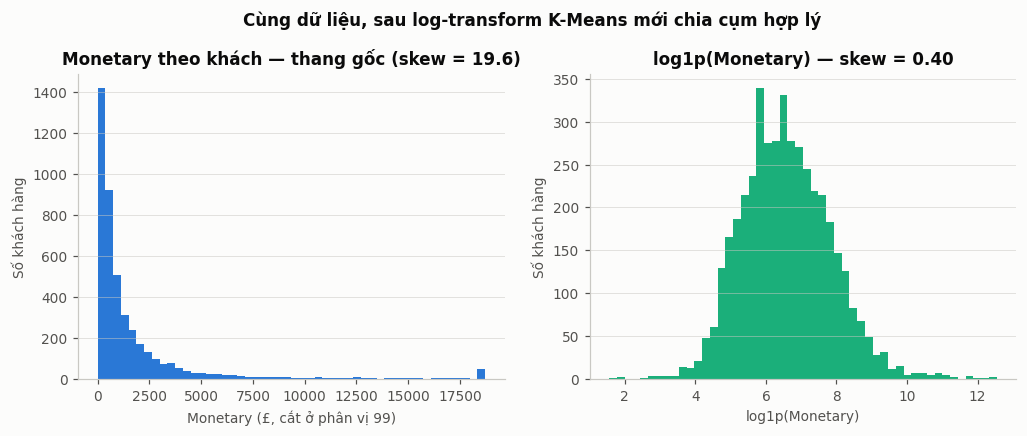

In [50]:
# Skewness ở cấp KHÁCH HÀNG (mức mà K-Means thực sự nhìn thấy)
rfm_base = df[(~df.IsCancelled) & (~df.IsServiceCode) & df.HasCustomerID & (df.TotalPrice > 0)]
monetary = rfm_base.groupby("Customer ID").TotalPrice.sum()
frequency = rfm_base.groupby("Customer ID").Invoice.nunique()

print(f"Số khách hàng đủ điều kiện tính RFM: {len(monetary):,}")
print(f"skew(Monetary)  = {skew(monetary):7.3f}  →  sau log1p: {skew(np.log1p(monetary)):6.3f}")
print(f"skew(Frequency) = {skew(frequency):7.3f}  →  sau log1p: {skew(np.log1p(frequency)):6.3f}")
display(monetary.describe().to_frame("Monetary/khách").round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(monetary.clip(upper=monetary.quantile(0.99)), bins=50, color=BLUE)
axes[0].set_title(f"Monetary theo khách — thang gốc (skew = {skew(monetary):.1f})")
axes[0].set_xlabel("Monetary (£, cắt ở phân vị 99)")
axes[1].hist(np.log1p(monetary), bins=50, color=AQUA)
axes[1].set_title(f"log1p(Monetary) — skew = {skew(np.log1p(monetary)):.2f}")
axes[1].set_xlabel("log1p(Monetary)")
for ax in axes:
    ax.set_ylabel("Số khách hàng")
    ax.grid(axis="y")
fig.suptitle("Cùng dữ liệu, sau log-transform K-Means mới chia cụm hợp lý",
             fontsize=11, fontweight="bold", color=INK, y=1.04)
plt.show()

In [51]:
# So sánh nhóm thiếu Customer ID vs có Customer ID
cust_cmp = df.groupby("HasCustomerID").agg(
    số_dòng=("TotalPrice", "size"),
    tổng_TotalPrice=("TotalPrice", "sum"),
    TP_trung_bình=("TotalPrice", "mean"),
    TP_trung_vị=("TotalPrice", "median"),
    Quantity_trung_vị=("Quantity", "median"),
    Price_trung_vị=("Price", "median"),
    tỷ_lệ_hủy=("IsCancelled", "mean"),
    tỷ_lệ_mã_dịch_vụ=("IsServiceCode", "mean"),
    tỷ_lệ_giá_0=("PriceAnomaly", "mean"),
).round(3)
cust_cmp[["tỷ_lệ_hủy", "tỷ_lệ_mã_dịch_vụ", "tỷ_lệ_giá_0"]] *= 100
display(cust_cmp.rename(index={True: "Có Customer ID", False: "Thiếu Customer ID"}))

nul = df[~df.HasCustomerID]
has = df[df.HasCustomerID]
print(f"Nhóm thiếu Customer ID: {len(nul)/len(df)*100:.2f}% số dòng nhưng chỉ "
      f"{nul.TotalPrice.sum()/df.TotalPrice.sum()*100:.2f}% tổng TotalPrice.")
print(f"Số hóa đơn: {nul.Invoice.nunique():,} | Số dòng/hóa đơn (trung vị): "
      f"{nul.groupby('Invoice').size().median():.0f} (nhóm có ID: {has.groupby('Invoice').size().median():.0f})")
print(f"Giá trị hóa đơn trung vị: {money(nul.groupby('Invoice').TotalPrice.sum().median())} "
      f"(nhóm có ID: {money(has.groupby('Invoice').TotalPrice.sum().median())})")
print(f"Thiếu Description: {nul.Description.isna().mean()*100:.2f}% (nhóm có ID: {has.Description.isna().mean()*100:.2f}%)")

,số_dòng,tổng_TotalPrice,TP_trung_bình,TP_trung_vị,Quantity_trung_vị,Price_trung_vị,tỷ_lệ_hủy,tỷ_lệ_mã_dịch_vụ,tỷ_lệ_giá_0
HasCustomerID,,,,,,,,,
Thiếu Customer ID,135037,"1,447,487.53",10.72,4.96,1.00,3.29,0.30,0.70,1.80
Có Customer ID,401605,"8,278,537.42",20.61,11.70,5.00,1.95,2.20,0.50,0.00


Nhóm thiếu Customer ID: 25.16% số dòng nhưng chỉ 14.88% tổng TotalPrice.
Số hóa đơn: 3,710 | Số dòng/hóa đơn (trung vị): 1 (nhóm có ID: 12)
Giá trị hóa đơn trung vị: £0.00 (nhóm có ID: £239.41)
Thiếu Description: 1.08% (nhóm có ID: 0.00%)


In [52]:
# Nhóm thiếu ID có tập trung vào vài Country / StockCode nhất định không?
cty_cmp = pd.concat([
    nul.Country.value_counts(normalize=True).mul(100).rename("Thiếu ID (%)"),
    has.Country.value_counts(normalize=True).mul(100).rename("Có ID (%)"),
], axis=1).sort_values("Thiếu ID (%)", ascending=False).head(8)
display(cty_cmp.round(2))

print("Top StockCode trong nhóm thiếu Customer ID:")
display(nul.StockCode.value_counts().head(6).to_frame("số dòng"))

,Thiếu ID (%),Có ID (%)
Country,,
United Kingdom,98.92,88.83
EIRE,0.53,1.86
Hong Kong,0.21,NaN
Unspecified,0.15,0.06
Switzerland,0.09,0.47
France,0.05,2.11
Israel,0.03,0.06
Portugal,0.03,0.37


Top StockCode trong nhóm thiếu Customer ID:


,số dòng
StockCode,
DOT,694
85099B,497
21931,414
22411,388
20712,372
22197,358
